# Task 6: K-Nearest Neighbors (KNN) Classification

In [1]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap


In [3]:
# Step 2: Load and inspect the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_name

#Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# Step 3: Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
# Step 5: Train KNN with different K values and evaluate
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    print(f"K = {k}: Accuracy = {acc:.2f}")


K = 1: Accuracy = 0.97
K = 2: Accuracy = 1.00
K = 3: Accuracy = 1.00
K = 4: Accuracy = 1.00
K = 5: Accuracy = 1.00
K = 6: Accuracy = 1.00
K = 7: Accuracy = 1.00
K = 8: Accuracy = 1.00
K = 9: Accuracy = 1.00
K = 10: Accuracy = 1.00


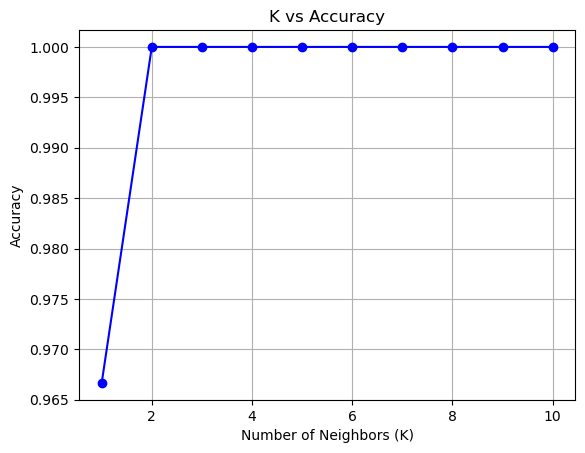

In [7]:
# Step 6: Plot accuracy vs K
plt.plot(k_values, accuracies, marker='o', color='blue')
plt.title('K vs Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


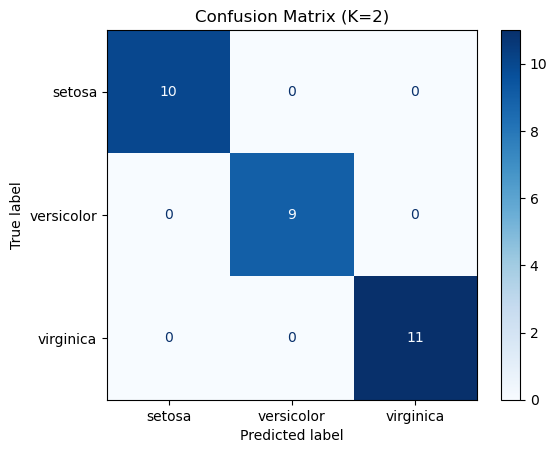

In [8]:
# Step 7: Confusion Matrix for best K
best_k = k_values[np.argmax(accuracies)]
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()


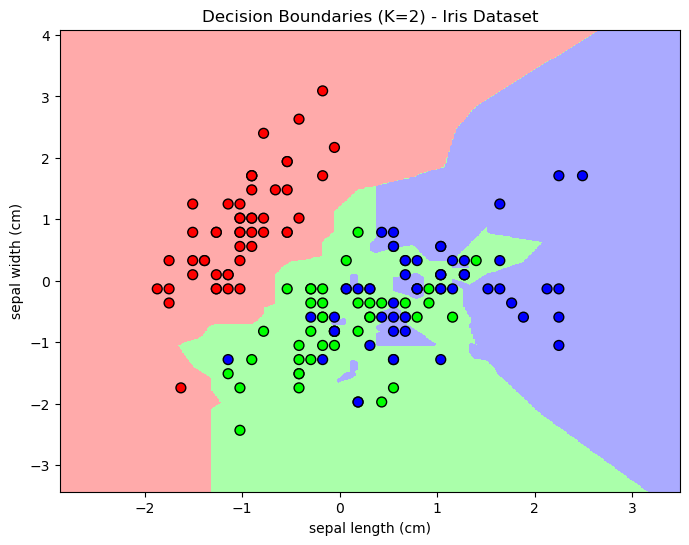

In [9]:
# Step 8: Visualize Decision Boundaries (using only 2 features for plotting)
X_2d = X[:, :2]  # Only first 2 features for 2D visualization
X_2d_scaled = scaler.fit_transform(X_2d)
X_train2d, X_test2d, y_train2d, y_test2d = train_test_split(X_2d_scaled, y, test_size=0.2, random_state=42)

model_2d = KNeighborsClassifier(n_neighbors=best_k)
model_2d.fit(X_train2d, y_train2d)

# Create a mesh grid
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
plt.contourf(xx, yy, Z, cmap=cmap_light)
plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title(f"Decision Boundaries (K={best_k}) - Iris Dataset")
plt.show()
